In [1]:
import numpy as np
import pandas as pd
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
import nltk
import seaborn as sns

In [7]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from numpy import array

from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense, Flatten, GlobalMaxPooling1D, Embedding, Conv1D, LSTM
from sklearn.model_selection import train_test_split

In [8]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Berkay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [127]:
def preprocess_text(text):
    sentence = text.lower()
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence

In [128]:
df = pd.read_csv("all_big_company_news.csv")
df = df.drop_duplicates(subset=["News_Title"])
df["id"] = df.index

In [129]:
df.head()

,Date,News_Title,Sentiment_Reasoning,Sentiment,id
0,2026-03-19,S&P 500 Slides Gold Crashes As $100 Oil Stokes...,Declined 0.73% as tech stocks underperformed a...,-1.0,0
1,2026-03-19,3 of the Best Energy Stocks to Buy Right Now,Increased cost savings from Pioneer Natural Re...,1.0,1
2,2026-03-19,Crashing 51% 3 Reasons to Buy This Netflix Riv...,Stock is trading at a significant discount (51...,1.0,2
4,2026-03-19,Where Could Palantir Be in 3 Years? The Base C...,The article highlights strong commercial reven...,1.0,4
5,2026-03-19,Can AI Make Home Loans Cheaper? Palantir Think...,Strategic partnership announcement demonstrate...,1.0,5


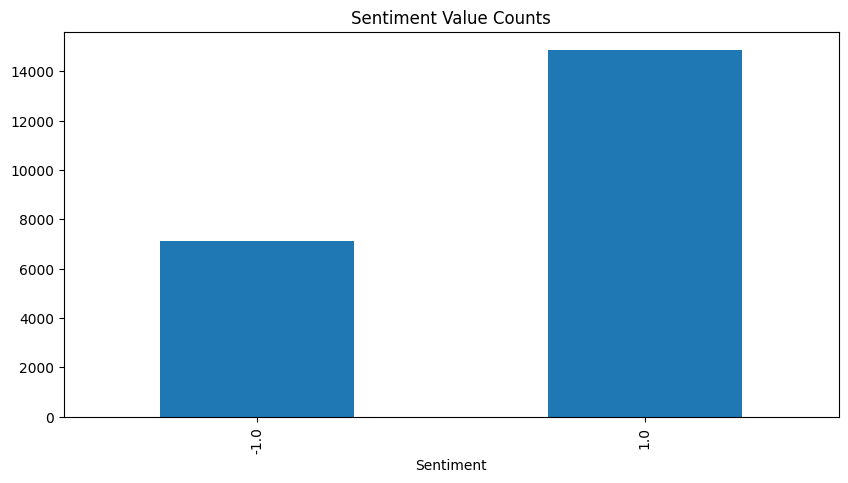

In [130]:
ax = df["Sentiment"].value_counts().sort_index().plot(kind="bar", title="Sentiment Value Counts", figsize=(10,5))
plt.show()

In [131]:
X = []
sentences = list(df["News_Title"])
for s in sentences:
    processed_text = preprocess_text(s)
    X.append(processed_text)

In [132]:
y = df["Sentiment"]

In [133]:
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [134]:
y_train = y_train.replace(-1, 0)
y_test = y_test.replace(-1, 0)

In [135]:
word_token = Tokenizer()
word_token.fit_on_texts(X_train)

In [136]:
X_train = word_token.texts_to_sequences(X_train)
X_test = word_token.texts_to_sequences(X_test)

In [137]:
vocab_len = len(word_token.word_index) + 1
vocab_len

10861

In [138]:
max_len=20
X_train = pad_sequences(X_train, padding="post", maxlen=max_len)
X_test = pad_sequences(X_test, padding="post", maxlen=max_len)

In [139]:
from numpy import asarray
from numpy import zeros

emb_dict = dict()
glove_file = open('LSTM_example_files/a2_glove.6B.100d.txt', encoding='utf-8')

for i in glove_file:
    line = i.split()
    word = line[0]
    word_vector = asarray(line[1:], dtype='float32')
    emb_dict[word] = word_vector
glove_file.close()

In [141]:

embed_matrix = zeros((vocab_len, 100))
for word, index in word_token.word_index.items():
    emb_vector = emb_dict.get(word)
    if emb_vector is not None:
        embed_matrix[index] = emb_vector

In [143]:
from keras.layers import LSTM

In [144]:
lstm_model = Sequential()
embedding_layer = Embedding(vocab_len, 100, weights=[embed_matrix], input_length=max_len, trainable=True)
lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [145]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

lstm_model.fit(X_train, y_train, batch_size=32, epochs=20, 
               verbose=1, validation_split=0.2, 
               callbacks=[early_stop],
               class_weight=class_weight_dict)

Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8392 - loss: 0.3874 - val_accuracy: 0.8629 - val_loss: 0.3709
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8829 - loss: 0.2914 - val_accuracy: 0.8595 - val_loss: 0.3027
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9021 - loss: 0.2391 - val_accuracy: 0.8663 - val_loss: 0.3010
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9196 - loss: 0.2001 - val_accuracy: 0.8543 - val_loss: 0.3519
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9345 - loss: 0.1674 - val_accuracy: 0.8788 - val_loss: 0.3008
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9462 - loss: 0.1397 - val_accuracy: 0.8680 - val_loss: 0.4649
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9555 - loss: 0.1159 - val_accuracy: 0.8734 - val_loss: 0.4303
Epoch 8/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9595 - loss: 0.1037 - val_accu

In [146]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_prob = lstm_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
0.8864360491579426
              precision    recall  f1-score   support

         0.0       0.88      0.75      0.81      1419
         1.0       0.89      0.95      0.92      2975

    accuracy                           0.89      4394
   macro avg       0.88      0.85      0.86      4394
weighted avg       0.89      0.89      0.88      4394

[[1069  350]
 [ 149 2826]]


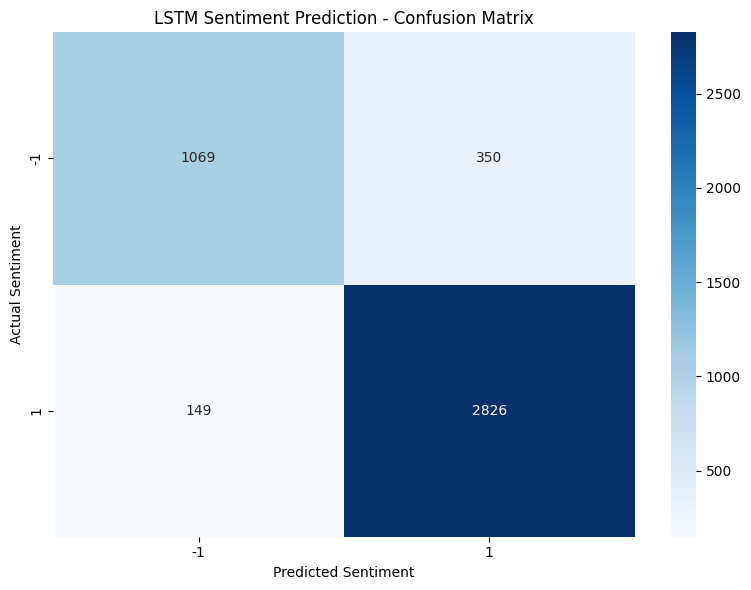

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[-1, 1], yticklabels=[-1, 1])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('LSTM Sentiment Prediction - Confusion Matrix')
plt.tight_layout()
plt.savefig('vader_confusion_matrix.png', dpi=150)
plt.show()